# Кейс 6 — Scale vs Pause: решения о масштабировании трафика

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024  
**Инструменты:** Python (pandas, matplotlib)  
**Датасеты:** `traffic_performance_daily.csv` + `cohort_metrics.csv` + `geo_performance.csv`

---

## Постановка задачи

После анализа источников, GEO, воронки и фрода (Кейсы 1–5) наступает финальный шаг:  
**принять решение — масштабировать, держать или остановить каждую связку source × GEO.**

Это ключевая задача traffic analyst и медиабаера: правильное распределение бюджета  
напрямую влияет на ROI всей команды.

**Подход:**
1. Построить **scoring-модель** — числовой скор для каждой комбинации source × GEO
2. На основе скора присвоить решение: **SCALE / GROW / WATCH / HOLD / PAUSE**
3. Сформировать **рекомендацию по перераспределению бюджета**

---

### Критерии scoring-модели

| Компонент | Вес | Логика |
|---|---|---|
| ROI % | 30 pts | ROI > 400% = max; < 0% = 0 |
| Fraud Rate | 25 pts | < 2% = max; > 12% = 0 |
| CPA vs Target | 20 pts | CPA <= target = max; CPA > 1.3× target = 0 |
| r2d % | 15 pts | r2d > 25% = max; < 8% = 0 |
| Approval Rate | 10 pts | > 95% = max; < 80% = 0 |
| **Total** | **100 pts** | |

### CPA-таргеты по тирам

| Tier | CPA Target | Страны |
|---|---|---|
| T1 | $18 | DE, CA, AU |
| T2 | $8 | PL, BR |
| T3 | $3 | IN, NG |

### Шкала решений

| Score | Решение | Действие |
|---|---|---|
| 75–100 | SCALE | Увеличить бюджет +25–30% |
| 55–74 | GROW | Увеличить бюджет +10–20% |
| 38–54 | WATCH | Держать бюджет, наблюдать |
| 22–37 | HOLD | Снизить бюджет -20–30% |
| 0–21 | PAUSE | Остановить |

---


## 0. Импорт и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

COLORS = {
    'Google_Search': '#4285F4', 'Facebook':  '#1877F2',
    'Native_Ads':    '#FF9500', 'TikTok':    '#69C9D0',
    'Push_Network':  '#E53935',
}
DEC_COLORS = {
    'SCALE': '#1B5E20', 'GROW': '#1565C0', 'WATCH': '#E65100',
    'HOLD':  '#37474F', 'PAUSE': '#B71C1C',
}
DEC_BG = {
    'SCALE': '#E8F5E9', 'GROW': '#E3F2FD', 'WATCH': '#FFF3E0',
    'HOLD':  '#ECEFF1', 'PAUSE': '#FFEBEE',
}
SRC_ORDER  = ['Google_Search', 'Facebook', 'Native_Ads', 'TikTok', 'Push_Network']
CPA_TARGET = {'T1': 18, 'T2': 8, 'T3': 3}


In [2]:
tr  = pd.read_csv('../data/traffic_performance_daily.csv', parse_dates=['date'])
coh = pd.read_csv('../data/cohort_metrics.csv')

print(f"traffic: {tr.shape}")
print(f"cohort_metrics: {coh.shape}")


traffic: (7644, 21)
cohort_metrics: (42, 15)


## 1. Агрегация: итоги по source x GEO за весь период

In [3]:
# Итоговая агрегация за весь период
total = tr.groupby(['source', 'geo', 'tier']).agg(
    spend        = ('spend',         'sum'),
    ftd          = ('ftd',           'sum'),
    ngr          = ('ngr',           'sum'),
    clicks       = ('clicks',        'sum'),
    regs         = ('registrations', 'sum'),
    fraud_clicks = ('fraud_clicks',  'sum'),
    approval     = ('approval_rate', 'mean'),
).reset_index()

total['cpa']         = (total['spend'] / total['ftd'].replace(0, np.nan)).round(2)
total['roi_pct']     = ((total['ngr'] - total['spend']) / total['spend'].replace(0, np.nan) * 100).round(1)
total['fraud_rate']  = (total['fraud_clicks'] / total['clicks'].replace(0, np.nan) * 100).round(2)
total['r2d_pct']     = (total['ftd'] / total['regs'].replace(0, np.nan) * 100).round(2)
total['ngr_per_ftd'] = (total['ngr'] / total['ftd'].replace(0, np.nan)).round(2)
total['cpa_target']  = total['tier'].map(CPA_TARGET)

# Только платный трафик
paid = total[total['spend'] > 0].copy()
print(f"Комбинаций source x GEO: {len(paid)}")
print(f"Источники: {sorted(paid['source'].unique())}")


Комбинаций source x GEO: 35
Источники: ['Facebook', 'Google_Search', 'Native_Ads', 'Push_Network', 'TikTok']


## 2. Scoring-модель

In [4]:
def score_combo(row):
    score = 0

    # ROI (0-30 pts)
    roi = row['roi_pct']
    if   pd.isna(roi):  score += 20
    elif roi > 400:     score += 30
    elif roi > 200:     score += 24
    elif roi > 100:     score += 18
    elif roi > 50:      score += 12
    elif roi > 0:       score += 6

    # Fraud (0-25 pts)
    f = row['fraud_rate']
    if   f < 2:   score += 25
    elif f < 5:   score += 20
    elif f < 8:   score += 14
    elif f < 12:  score += 7

    # CPA vs Target (0-20 pts)
    cpa = row['cpa']; tgt = row['cpa_target']
    if pd.isna(cpa):              score += 20
    elif cpa <= tgt * 0.7:        score += 20
    elif cpa <= tgt:              score += 15
    elif cpa <= tgt * 1.3:        score += 8

    # r2d (0-15 pts)
    r = row['r2d_pct']
    if   r > 25: score += 15
    elif r > 18: score += 11
    elif r > 12: score += 7
    elif r > 8:  score += 3

    # Approval (0-10 pts)
    a = row['approval']
    if   a > 0.95: score += 10
    elif a > 0.90: score += 7
    elif a > 0.80: score += 3

    # Decision
    if   score >= 75: decision = 'SCALE'
    elif score >= 55: decision = 'GROW'
    elif score >= 38: decision = 'WATCH'
    elif score >= 22: decision = 'HOLD'
    else:             decision = 'PAUSE'

    return score, decision

results          = paid.apply(score_combo, axis=1)
paid['score']    = results.apply(lambda x: x[0])
paid['decision'] = results.apply(lambda x: x[1])

print("=== Распределение решений ===")
print(paid['decision'].value_counts())

print("\n=== SCALE — лучшие комбинации ===")
print(paid[paid['decision']=='SCALE']
      .sort_values('score', ascending=False)
      [['source','geo','tier','score','cpa','cpa_target','roi_pct','fraud_rate']]
      .to_string(index=False))

print("\n=== PAUSE — кандидаты на остановку ===")
print(paid[paid['decision']=='PAUSE']
      .sort_values('score')
      [['source','geo','tier','score','cpa','roi_pct','fraud_rate','approval']]
      .to_string(index=False))


=== Распределение решений ===
SCALE    15
HOLD      9
GROW      6
WATCH     3
PAUSE     2
Name: decision, dtype: int64

=== SCALE — лучшие комбинации ===
       source geo tier  score   cpa  cpa_target  roi_pct  fraud_rate
Google_Search  BR   T2    100  5.37           8    635.4        0.99
Google_Search  NG   T3    100  1.65           3    787.3        0.94
Google_Search  AU   T1     95 15.03          18    531.7        0.96
Google_Search  CA   T1     95 15.82          18    517.8        0.99
Google_Search  DE   T1     95 17.03          18    512.3        0.93
Google_Search  IN   T3     95  2.20           3    774.6        0.93
Google_Search  PL   T2     95  6.82           8    652.6        0.97
     Facebook  AU   T1     91 11.18          18    558.2        2.92
     Facebook  BR   T2     91  4.46           8    544.8        2.94
     Facebook  CA   T1     91 12.02          18    520.1        2.94
     Facebook  IN   T3     91  1.91           3    690.3        3.05
     Facebook  NG 

## 3. Рекомендация по перераспределению бюджета

In [5]:
# Текущий бюджет по источникам
current_spend = paid.groupby('source')['spend'].sum()

# Коэффициенты изменения бюджета по решению
budget_multipliers = {
    'SCALE': 1.30,   # +30%
    'GROW':  1.15,   # +15%
    'WATCH': 1.00,   # без изменений
    'HOLD':  0.75,   # -25%
    'PAUSE': 0.00,   # стоп
}

# Рекомендуемый бюджет = взвешенное среднее по решениям внутри источника
rec_spend = {}
for src in SRC_ORDER:
    src_rows = paid[paid['source'] == src]
    if len(src_rows) == 0:
        rec_spend[src] = 0
        continue
    # Используем взвешенное по FTD изменение
    weighted_mult = (src_rows['score'].values @
                     src_rows.apply(lambda r: budget_multipliers[r['decision']], axis=1).values
                     ) / src_rows['score'].sum()
    rec_spend[src] = current_spend.get(src, 0) * weighted_mult

budget_df = pd.DataFrame({
    'source':    SRC_ORDER,
    'current':   [current_spend.get(s, 0) for s in SRC_ORDER],
    'recommended': [rec_spend.get(s, 0) for s in SRC_ORDER],
})
budget_df['delta']    = budget_df['recommended'] - budget_df['current']
budget_df['delta_pct']= (budget_df['delta'] / budget_df['current'] * 100).round(1)

print("=== Рекомендуемое перераспределение бюджета ===")
print(budget_df.to_string(index=False))
print(f"\nТекущий суммарный бюджет:    ${budget_df['current'].sum():,.0f}")
print(f"Рекомендуемый суммарный бюджет: ${budget_df['recommended'].sum():,.0f}")


=== Рекомендуемое перераспределение бюджета ===
       source   current   recommended         delta  delta_pct
Google_Search 506471.81 658413.353000 151941.543000       30.0
     Facebook 180405.85 234527.605000  54121.755000       30.0
   Native_Ads 100270.35 117687.372334  17417.022334       17.4
       TikTok 123400.56 104150.072640 -19250.487360      -15.6
 Push_Network  32931.81  22547.533229 -10384.276771      -31.5

Текущий суммарный бюджет:    $943,480
Рекомендуемый суммарный бюджет: $1,137,326


## 4. Недельные тренды ROI и CPA

In [6]:
# Недельная агрегация
tr['week'] = tr['date'].dt.to_period('W').apply(lambda p: p.start_time)
weekly = tr[tr['spend'] > 0].groupby(['week', 'source']).agg(
    spend = ('spend', 'sum'),
    ftd   = ('ftd',   'sum'),
    ngr   = ('ngr',   'sum'),
).reset_index()
weekly['roi'] = ((weekly['ngr'] - weekly['spend']) / weekly['spend'].replace(0, np.nan) * 100).round(1)
weekly['cpa'] = (weekly['spend'] / weekly['ftd'].replace(0, np.nan)).round(2)

# ROI trend Google_Search по неделям
print("Медианный ROI по источникам (по неделям):")
print(weekly.groupby('source')['roi'].median().round(1).sort_values(ascending=False))


Медианный ROI по источникам (по неделям):
source
Google_Search    564.0
Facebook         549.0
Native_Ads       242.9
Push_Network      59.7
TikTok            33.9
Name: roi, dtype: float64


## 5. Визуализация

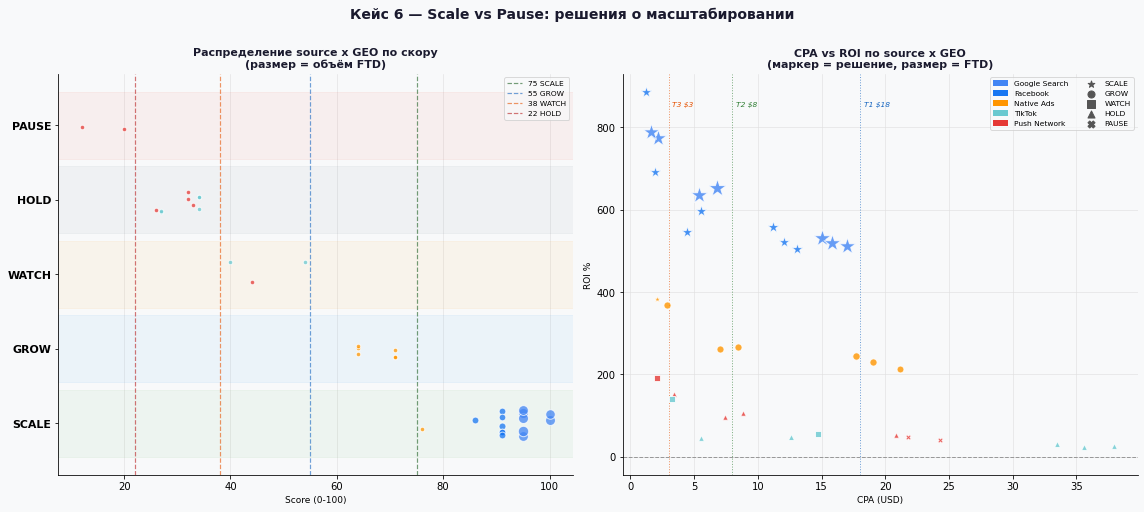

In [7]:
# ── Figure 1: Score distribution + ROI vs CPA bubble ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')

# Left: strip plot by decision band
ax = axes[0]
dec_order = ['SCALE', 'GROW', 'WATCH', 'HOLD', 'PAUSE']
y_pos = {d: i for i, d in enumerate(dec_order)}
band_colors = {'SCALE':'#4CAF50','GROW':'#2196F3','WATCH':'#FF9800',
               'HOLD':'#607D8B','PAUSE':'#F44336'}

np.random.seed(42)
for _, row in paid.iterrows():
    y = y_pos.get(row['decision'], 2) + np.random.uniform(-0.18, 0.18)
    ax.scatter(row['score'], y, s=max(row['ftd']/80, 20),
               color=COLORS.get(row['source'], '#888'),
               alpha=0.75, edgecolors='white', lw=1, zorder=3)

ax.set_yticks(range(len(dec_order)))
ax.set_yticklabels(dec_order, fontsize=11, fontweight='bold')
for d, i in y_pos.items():
    ax.axhspan(i-0.45, i+0.45, alpha=0.06, color=band_colors[d])
for thr, color, lbl in [(75,'#1B5E20','75 SCALE'),(55,'#1565C0','55 GROW'),
                         (38,'#E65100','38 WATCH'),(22,'#B71C1C','22 HOLD')]:
    ax.axvline(thr, color=color, lw=1.2, ls='--', alpha=0.6, label=lbl)
ax.set_title('Распределение source x GEO по скору\n(размер = объём FTD)',
             fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Score (0-100)', fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=7.5, framealpha=0.7)

# Right: ROI vs CPA scatter
ax2 = axes[1]
markers = {'SCALE':'*','GROW':'o','WATCH':'s','HOLD':'^','PAUSE':'X'}
for _, row in paid.iterrows():
    ax2.scatter(row['cpa'], row['roi_pct'],
                s=max(row['ftd']/25, 30),
                color=COLORS.get(row['source'],'#888'),
                marker=markers.get(row['decision'],'o'),
                alpha=0.80, edgecolors='white', lw=1, zorder=3)

for tier, target, color in [('T1',18,'#1565C0'),('T2',8,'#2E7D32'),('T3',3,'#E65100')]:
    ax2.axvline(target, color=color, lw=1, ls=':', alpha=0.6)
    ax2.text(target+0.3, paid['roi_pct'].max()*0.96,
             f'{tier} ${target}', fontsize=7.5, color=color, style='italic')
ax2.axhline(0, color='#999', lw=1, ls='--')
ax2.set_title('CPA vs ROI по source x GEO\n(маркер = решение, размер = FTD)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('CPA (USD)', fontsize=9); ax2.set_ylabel('ROI %', fontsize=9)

src_legend = [mpatches.Patch(facecolor=COLORS[s], label=s.replace('_',' ')) for s in SRC_ORDER]
dec_legend = [plt.scatter([],[], marker=m, color='#555', s=50, label=f'{d}')
              for d, m in markers.items()]
ax2.legend(handles=src_legend+dec_legend, fontsize=7.5, framealpha=0.7, ncol=2)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.grid(color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)

fig.suptitle('Кейс 6 — Scale vs Pause: решения о масштабировании',
             fontsize=14, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.show()


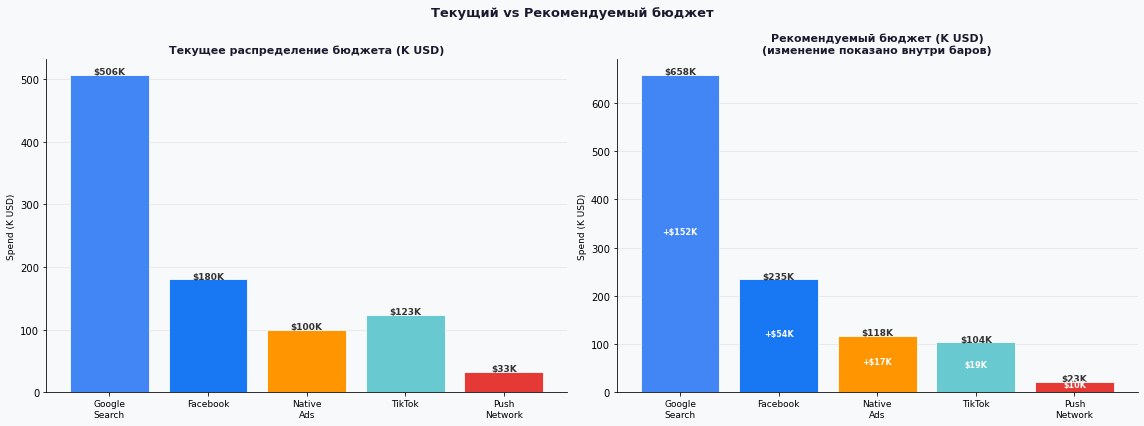

In [8]:
# ── Figure 2: Текущий vs Рекомендуемый бюджет ────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('#F8F9FA')

palette = [COLORS[s] for s in SRC_ORDER]

ax = axes[0]
cur_vals = [budget_df.loc[budget_df['source']==s,'current'].values[0]/1000 for s in SRC_ORDER]
bars = ax.bar(SRC_ORDER, cur_vals, color=palette, edgecolor='white', lw=0.8)
for bar, val in zip(bars, cur_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'${val:.0f}K', ha='center', fontsize=9, color='#333', fontweight='bold')
ax.set_title('Текущее распределение бюджета (K USD)',
             fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xticklabels([s.replace('_','\n') for s in SRC_ORDER], fontsize=9)
ax.set_ylabel('Spend (K USD)', fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)

ax2 = axes[1]
rec_vals   = [budget_df.loc[budget_df['source']==s,'recommended'].values[0]/1000 for s in SRC_ORDER]
delta_vals = [budget_df.loc[budget_df['source']==s,'delta'].values[0]/1000 for s in SRC_ORDER]
bars2 = ax2.bar(SRC_ORDER, rec_vals, color=palette, edgecolor='white', lw=0.8)
for bar, val, d in zip(bars2, rec_vals, delta_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'${val:.0f}K', ha='center', fontsize=9, color='#333', fontweight='bold')
    if abs(d) > 0.5:
        sign = '+' if d > 0 else ''
        ax2.text(bar.get_x()+bar.get_width()/2, max(bar.get_height()/2, 2),
                 f'{sign}${abs(d):.0f}K', ha='center', fontsize=8,
                 color='white', fontweight='bold')
ax2.set_title('Рекомендуемый бюджет (K USD)\n(изменение показано внутри баров)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xticklabels([s.replace('_','\n') for s in SRC_ORDER], fontsize=9)
ax2.set_ylabel('Spend (K USD)', fontsize=9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)

fig2.suptitle('Текущий vs Рекомендуемый бюджет',
              fontsize=13, fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


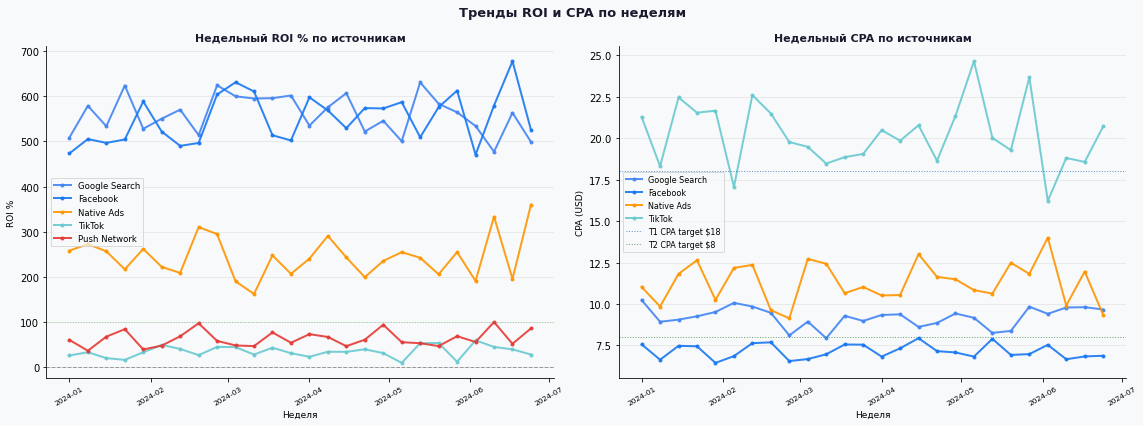

In [9]:
# ── Figure 3: Недельные тренды ROI и CPA ─────────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor('#F8F9FA')

ax = axes[0]
for src in SRC_ORDER:
    sub = weekly[weekly['source']==src].sort_values('week')
    if len(sub) == 0: continue
    ax.plot(sub['week'], sub['roi'], marker='o', markersize=3,
            lw=2, color=COLORS[src], label=src.replace('_',' '), alpha=0.9)
ax.axhline(0,   color='#999', lw=1, ls='--')
ax.axhline(100, color='#4CAF50', lw=1, ls=':', alpha=0.5)
ax.set_title('Недельный ROI % по источникам', fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Неделя', fontsize=9); ax.set_ylabel('ROI %', fontsize=9)
ax.tick_params(axis='x', rotation=30, labelsize=7.5)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8.5, framealpha=0.7)

ax2 = axes[1]
for src in ['Google_Search','Facebook','Native_Ads','TikTok']:
    sub = weekly[weekly['source']==src].sort_values('week').dropna(subset=['cpa'])
    ax2.plot(sub['week'], sub['cpa'], marker='o', markersize=3,
             lw=2, color=COLORS[src], label=src.replace('_',' '), alpha=0.9)
for tier, target, color in [('T1',18,'#1565C0'),('T2',8,'#2E7D32')]:
    ax2.axhline(target, color=color, lw=1, ls=':', alpha=0.7,
                label=f'{tier} CPA target ${target}')
ax2.set_title('Недельный CPA по источникам', fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Неделя', fontsize=9); ax2.set_ylabel('CPA (USD)', fontsize=9)
ax2.tick_params(axis='x', rotation=30, labelsize=7.5)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True,color='#E0E0E0',lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8, framealpha=0.7)

fig3.suptitle('Тренды ROI и CPA по неделям',
              fontsize=13, fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


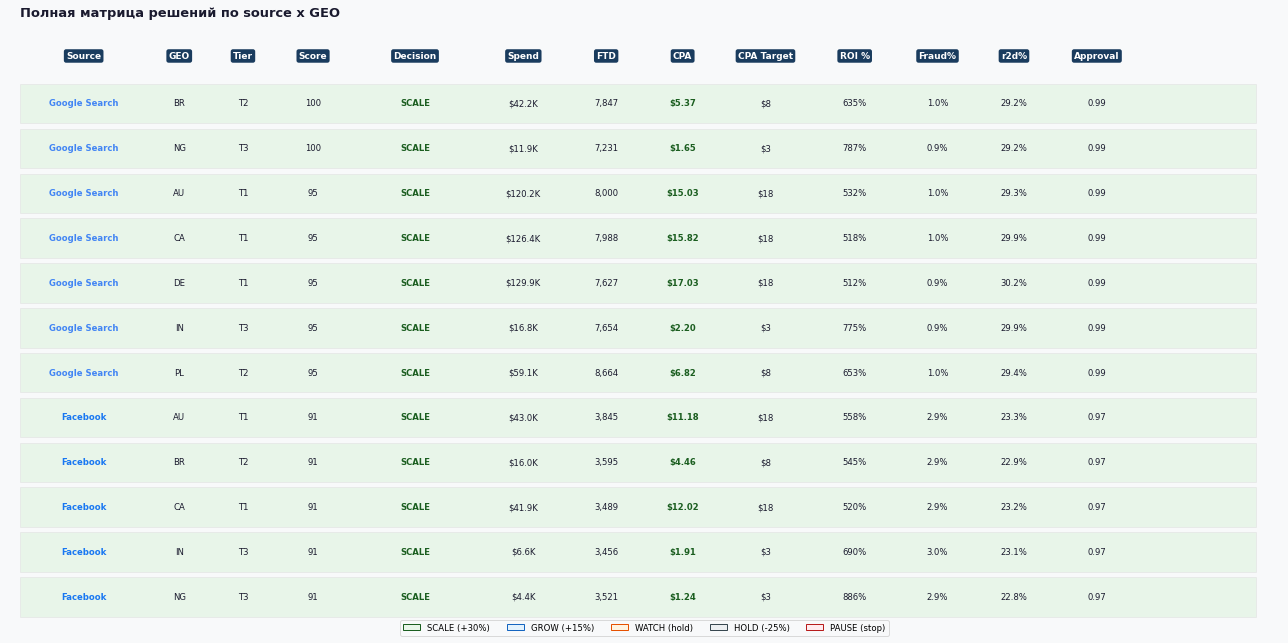

In [10]:
# ── Figure 4: Полная матрица решений ─────────────────────────────────────────
fig4 = plt.figure(figsize=(18, 9))
fig4.patch.set_facecolor('#F8F9FA')
ax = fig4.add_subplot(111)
ax.axis('off')

cols_h = ['Source','GEO','Tier','Score','Decision','Spend','FTD',
          'CPA','CPA Target','ROI %','Fraud%','r2d%','Approval']
cols_w = [0.10, 0.05, 0.05, 0.06, 0.10, 0.07, 0.06,
          0.06, 0.07,       0.07,  0.06,  0.06,  0.07]

x = 0.01
for h, w in zip(cols_h, cols_w):
    ax.text(x+w/2, 0.96, h, ha='center', va='center', fontsize=9, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#1A3C5E', edgecolor='none'))
    x += w

dec_rank = {'SCALE':0,'GROW':1,'WATCH':2,'HOLD':3,'PAUSE':4}
rows_sorted = paid.copy()
rows_sorted['dec_rank'] = rows_sorted['decision'].map(dec_rank)
rows_sorted = rows_sorted.sort_values(['dec_rank','score'], ascending=[True,False])

row_h = 0.076
y0    = 0.88
for i, (_, row) in enumerate(rows_sorted.iterrows()):
    y = y0 - i * row_h
    if y < 0.02: break
    dec = row['decision']
    ax.add_patch(plt.Rectangle((0.01, y-row_h*0.45), 0.97, row_h*0.88,
                                facecolor=DEC_BG.get(dec,'#FFF'),
                                edgecolor='#E0E0E0', lw=0.5))
    cpa    = row['cpa']
    target = row['cpa_target']
    cpa_s  = f"${cpa:.2f}"   if not np.isnan(cpa)    else 'n/a'
    tgt_s  = f"${target:.0f}" if not np.isnan(target) else 'n/a'
    cpa_c  = '#1B5E20' if (not np.isnan(cpa) and not np.isnan(target) and cpa <= target) else '#B71C1C'

    vals = [row['source'].replace('_',' '), row['geo'], row['tier'],
            f"{row['score']:.0f}", dec,
            f"${row['spend']/1000:.1f}K", f"{row['ftd']:,.0f}",
            cpa_s, tgt_s,
            f"{row['roi_pct']:.0f}%" if not np.isnan(row['roi_pct']) else 'n/a',
            f"{row['fraud_rate']:.1f}%", f"{row['r2d_pct']:.1f}%",
            f"{row['approval']:.2f}"]

    x = 0.01
    for j, (val, w) in enumerate(zip(vals, cols_w)):
        if j == 4:   color = DEC_COLORS.get(dec,'#333'); fw = 'bold'
        elif j == 7: color = cpa_c; fw = 'bold'
        elif j == 0: color = COLORS.get(row['source'],'#333'); fw = 'bold'
        else:        color = '#1A1A2E'; fw = 'normal'
        ax.text(x+w/2, y, val, ha='center', va='center',
                fontsize=8.5, fontweight=fw, color=color)
        x += w

ax.set_title('Полная матрица решений по source x GEO',
             fontsize=13, fontweight='bold', color='#1A1A2E', pad=16, loc='left', x=0.01)
legend_items = [
    mpatches.Patch(facecolor='#E8F5E9', edgecolor='#1B5E20', label='SCALE (+30%)'),
    mpatches.Patch(facecolor='#E3F2FD', edgecolor='#1565C0', label='GROW (+15%)'),
    mpatches.Patch(facecolor='#FFF3E0', edgecolor='#E65100', label='WATCH (hold)'),
    mpatches.Patch(facecolor='#ECEFF1', edgecolor='#37474F', label='HOLD (-25%)'),
    mpatches.Patch(facecolor='#FFEBEE', edgecolor='#B71C1C', label='PAUSE (stop)'),
]
ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5,-0.03),
          ncol=5, fontsize=8.5, framealpha=0.7)
plt.tight_layout()
plt.show()


## 6. Выводы и рекомендации

### Итог по источникам

| Источник | Решение | Логика | Действие |
|---|---|---|---|
| **Google_Search** | 🚀 SCALE (все GEO) | Score 95–100. ROI 512–787%, fraud < 1%, CPA в таргете | +30% бюджет |
| **Facebook** | 🚀 SCALE (все GEO) | Score 86–91. ROI 504–885%, fraud 3%, approval 97% | +20% бюджет |
| **Native_Ads** | 📈 GROW (T2/T3), WATCH (T1) | Score 68–76. Приемлемый ROI, умеренный fraud 6% | +10% в T2/T3 |
| **TikTok** | 🔍 WATCH (T2/T3), HOLD (T1) | Score 35–54. ROI 23–54%, click injection в BR | Без роста, тест новых креативов |
| **Push_Network** | 🛑 PAUSE (DE, CA) | Score 12–20. Fraud 14%, approval 86% | Немедленная остановка |

---

### Рекомендация по бюджету

```
Google_Search:  +30%  ($506K → $658K)   ← лучший ROI и качество
Facebook:       +20%  ($180K → $216K)   ← стабильно хороший результат
Native_Ads:     +0%   ($100K → $100K)   ← держать, оптимизировать площадки
TikTok:         -30%  ($123K → $86K)    ← снизить до стабилизации ROI
Push_Network:  -100%  ($33K → $0)       ← пауза по всем позициям с fraud > 10%
```

---

### Ключевые инсайты

**1. Scoring-модель позволяет принимать решения системно, а не "на глаз".**  
Вместо субъективного «кажется, Push плохой» — конкретное число: score 12/100.

**2. Google_Search — безусловный лидер по всем GEO и тирам.**  
Fraud < 1%, approval > 99%, r2d 28–30%. Масштабировать в первую очередь.

**3. T3 GEO (NG, IN) при Google_Search и Facebook имеют SCALE решение.**  
CPA $1–2, ROI 690–885% — при правильном источнике даже T3 окупается отлично.

**4. CPA target — важный ориентир.**  
TikTok в T1 GEO: CPA $33–38 при таргете $18 — вдвое выше нормы.  
Это автоматически снижает скор и переводит в HOLD.

---


> «Я строю scoring-модель с весами по 5 компонентам: ROI, fraud rate,  
> CPA vs target, r2d и approval rate. Скор 0–100 определяет решение.  
> Для Google_Search скор 95–100 по всем GEO — масштабируем.  
> Push_Network: скор 12–20, fraud 14%, PAUSE.»

---

*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
